In [27]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from darts.metrics import mae, rmse

# Allow imports from src/
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_dataset
from src.models import (
    chronological_train_test_split,
    get_split_information,
    fit_naive_seasonal,
    forecast_naive_seasonal,
    fit_arima,
    forecast_arima,
)

## Dataset path

In [28]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "LD2011_2014.txt"

print("Dataset path:")
print(DATA_PATH)

Dataset path:
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt


## Load dataset

In [29]:
df = load_dataset(
    str(DATA_PATH)
)

print("Dataset shape:", df.shape)

display(df.head())

Loading dataset: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt


c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\src\data.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Raw shape: (140256, 371)
Dataset shape: (51894720, 3)


,timestamp,series_id,value
0,2011-01-01 00:15:00,MT_001,0.0
1,2011-01-01 00:30:00,MT_001,0.0
2,2011-01-01 00:45:00,MT_001,0.0
3,2011-01-01 01:00:00,MT_001,0.0
4,2011-01-01 01:15:00,MT_001,0.0


## selecting a series

In [30]:
SERIES_ID = "MT_001"

series_df = (
    df[df["series_id"] == SERIES_ID]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print(f"Selected series: {SERIES_ID}")
print(f"Observations: {len(series_df):,}")

display(series_df.head())

Selected series: MT_001
Observations: 140,256


,timestamp,series_id,value
0,2011-01-01 00:15:00,MT_001,0.0
1,2011-01-01 00:30:00,MT_001,0.0
2,2011-01-01 00:45:00,MT_001,0.0
3,2011-01-01 01:00:00,MT_001,0.0
4,2011-01-01 01:15:00,MT_001,0.0


## Darts Time series

In [31]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(
    series_df,
    time_col="timestamp",
    value_cols="value",
    fill_missing_dates=False,
)

print(series)

                        value
timestamp                    
2011-01-01 00:15:00  0.000000
2011-01-01 00:30:00  0.000000
2011-01-01 00:45:00  0.000000
2011-01-01 01:00:00  0.000000
2011-01-01 01:15:00  0.000000
...                       ...
2014-12-31 23:00:00  2.538071
2014-12-31 23:15:00  2.538071
2014-12-31 23:30:00  2.538071
2014-12-31 23:45:00  1.269036
2015-01-01 00:00:00  2.538071

shape: (140256, 1, 1), freq: 15min, size: 1.07 MB


## Train/Test split

In [32]:
TRAIN_RATIO = 0.80

train, test = chronological_train_test_split(
    series,
    train_ratio=TRAIN_RATIO,
)

print("Train/Test split information:")
split_info = get_split_information(
    train,
    test
)

for key, value in split_info.items():
    print(f"{key}: {value}")

Train/Test split information:
train_length: 112204
test_length: 28052
total_length: 140256
train_percentage: 79.99942961441934
test_percentage: 20.00057038558065
train_start: 2011-01-01 00:15:00
train_end: 2014-03-14 19:00:00
test_start: 2014-03-14 19:15:00
test_end: 2015-01-01 00:00:00


In [33]:
print("Train starts :", train.start_time())
print("Train ends   :", train.end_time())

print()

print("Test starts  :", test.start_time())
print("Test ends    :", test.end_time())

print()

print(
    "Chronological split valid:",
    train.end_time() < test.start_time()
)

Train starts : 2011-01-01 00:15:00
Train ends   : 2014-03-14 19:00:00

Test starts  : 2014-03-14 19:15:00
Test ends    : 2015-01-01 00:00:00

Chronological split valid: True


## Train/Test visualization

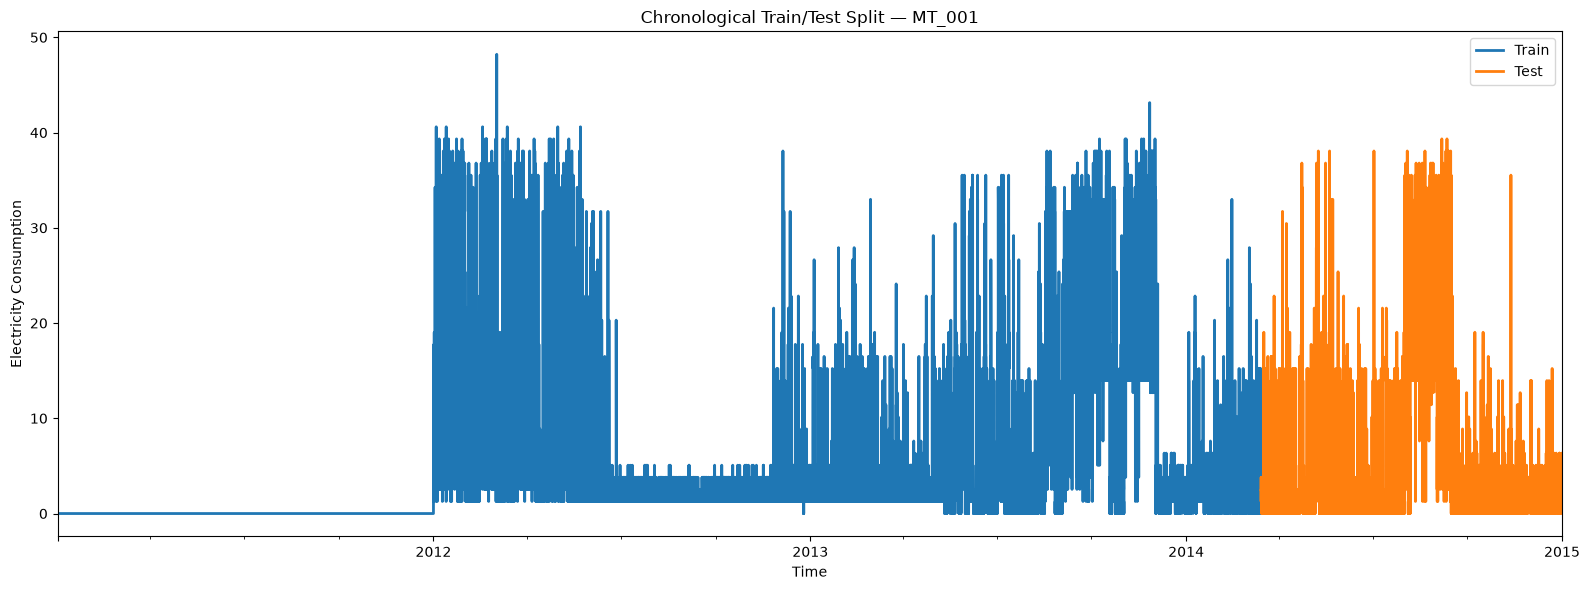

In [34]:
plt.figure(figsize=(16, 6))

train.plot(
    label="Train"
)

test.plot(
    label="Test"
)

plt.title(
    f"Chronological Train/Test Split — {SERIES_ID}"
)

plt.xlabel("Time")
plt.ylabel("Electricity Consumption")

plt.legend()
plt.tight_layout()
plt.show()

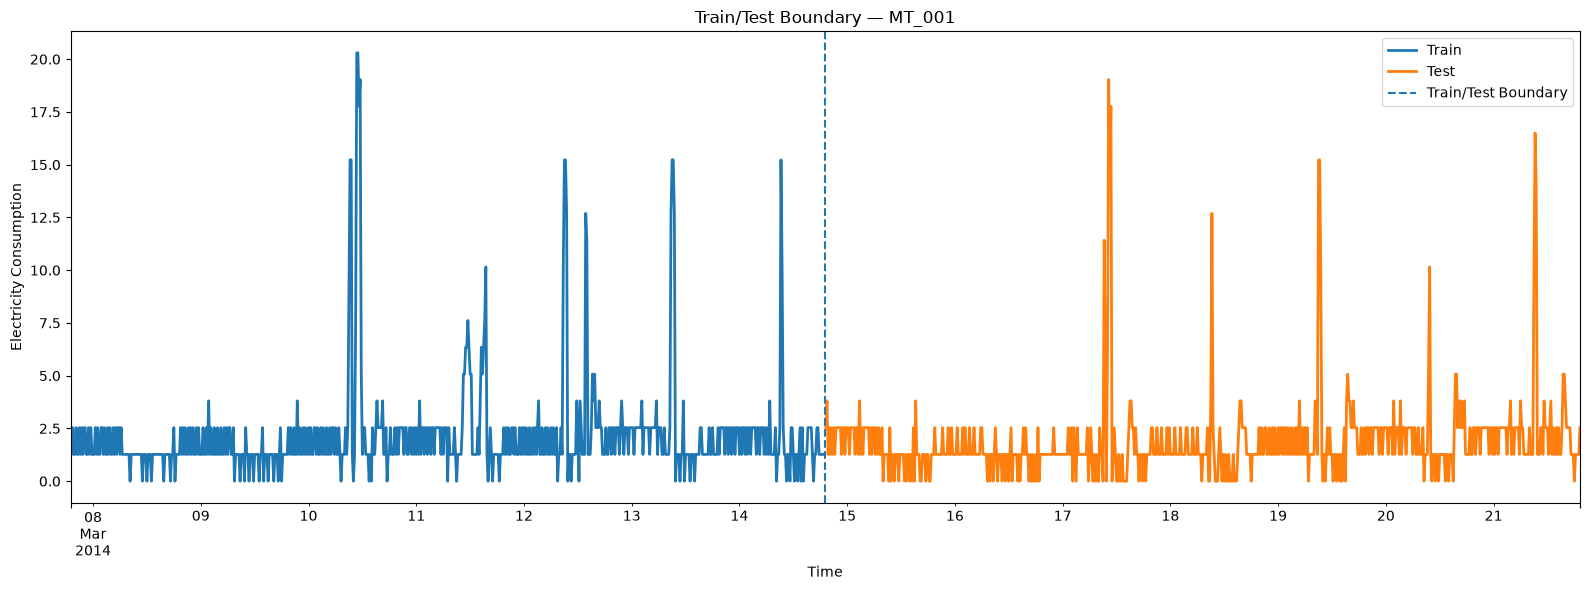

In [35]:
boundary_start = train.end_time() - pd.Timedelta(days=7)

train_boundary = train.slice(
    boundary_start,
    train.end_time()
)

test_boundary_end = test.start_time() + pd.Timedelta(days=7)

test_boundary = test.slice(
    test.start_time(),
    test_boundary_end
)

plt.figure(figsize=(16, 6))

train_boundary.plot(
    label="Train"
)

test_boundary.plot(
    label="Test"
)

plt.axvline(
    x=train.end_time(),
    linestyle="--",
    label="Train/Test Boundary"
)

plt.title(
    f"Train/Test Boundary — {SERIES_ID}"
)

plt.xlabel("Time")
plt.ylabel("Electricity Consumption")

plt.legend()
plt.tight_layout()
plt.show()

## Daily Naive Seasonal

In [36]:
DAILY_K = 96

daily_naive_model = fit_naive_seasonal(
    train=train,
    K=DAILY_K
)

daily_naive_forecast = daily_naive_model.predict(
    len(test)
)

print("Daily Naive Seasonal completed.")
print("K =", DAILY_K)
print("Forecast length =", len(daily_naive_forecast))

Daily Naive Seasonal completed.
K = 96
Forecast length = 28052


## Metrics

In [37]:
daily_naive_mae = mae(
    test,
    daily_naive_forecast
)

daily_naive_rmse = rmse(
    test,
    daily_naive_forecast
)

print(
    f"Daily Naive MAE  : {daily_naive_mae:.6f}"
)

print(
    f"Daily Naive RMSE : {daily_naive_rmse:.6f}"
)

Daily Naive MAE  : 3.556801
Daily Naive RMSE : 6.697063


In [38]:
DAILY_K = 192

daily_naive_model = fit_naive_seasonal(
    train=train,
    K=DAILY_K
)

daily_naive_forecast = daily_naive_model.predict(
    len(test)
)

print("Daily Naive Seasonal completed.")
print("K =", DAILY_K)
print("Forecast length =", len(daily_naive_forecast))

Daily Naive Seasonal completed.
K = 192
Forecast length = 28052


In [39]:
daily_naive_mae = mae(
    test,
    daily_naive_forecast
)

daily_naive_rmse = rmse(
    test,
    daily_naive_forecast
)

print(
    f"Daily Naive MAE  : {daily_naive_mae:.6f}"
)

print(
    f"Daily Naive RMSE : {daily_naive_rmse:.6f}"
)

Daily Naive MAE  : 3.566211
Daily Naive RMSE : 6.707616


## Weekly Naive Seasonal

In [40]:
WEEKLY_K = 672

weekly_naive_model = fit_naive_seasonal(
    train=train,
    K=WEEKLY_K
)

weekly_naive_forecast = weekly_naive_model.predict(
    len(test)
)

print("Weekly Naive Seasonal completed.")
print("K =", WEEKLY_K)
print(
    "Forecast length =",
    len(weekly_naive_forecast)
)

Weekly Naive Seasonal completed.
K = 672
Forecast length = 28052


## Metrics

In [41]:
weekly_naive_mae = mae(
    test,
    weekly_naive_forecast
)

weekly_naive_rmse = rmse(
    test,
    weekly_naive_forecast
)

print(
    f"Weekly Naive MAE  : {weekly_naive_mae:.6f}"
)

print(
    f"Weekly Naive RMSE : {weekly_naive_rmse:.6f}"
)

Weekly Naive MAE  : 3.650581
Weekly Naive RMSE : 6.793700


## visualize naive forecast

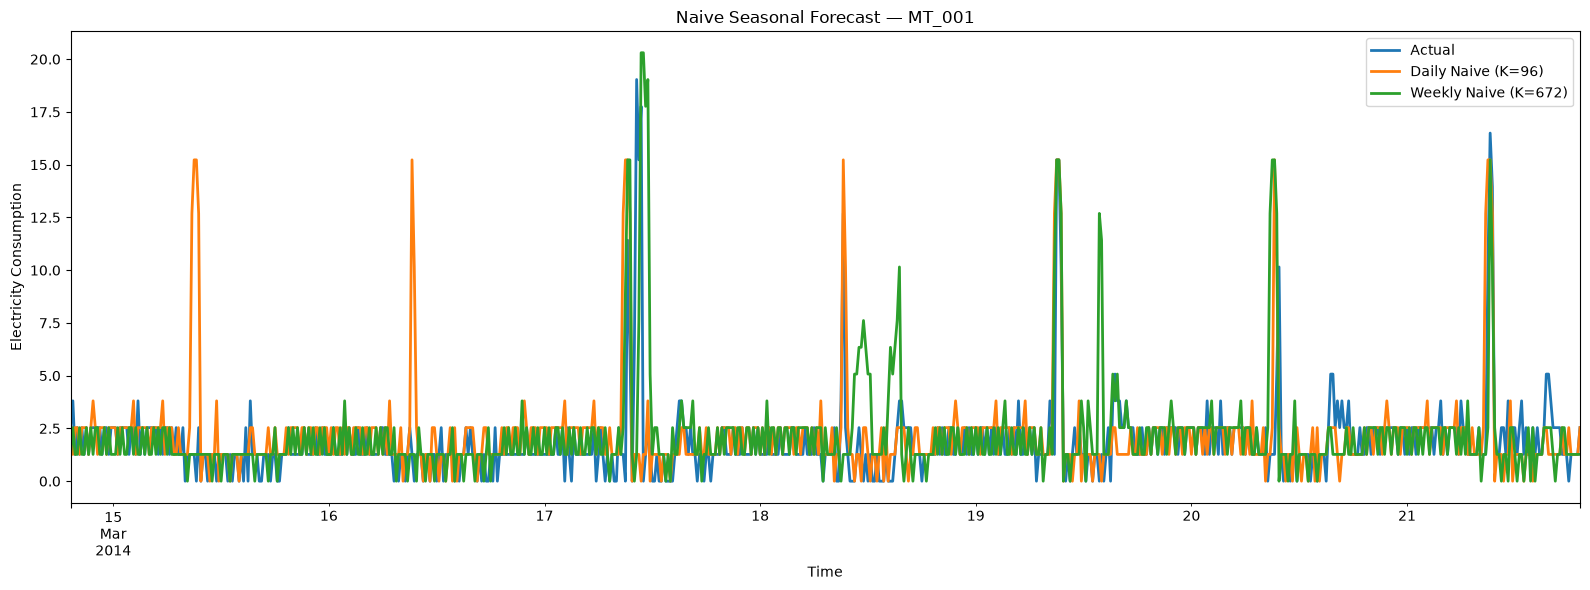

In [42]:
forecast_start = test.start_time()

forecast_end = (
    forecast_start
    + pd.Timedelta(days=7)
)

test_week = test.slice(
    forecast_start,
    forecast_end
)

daily_forecast_week = daily_naive_forecast.slice(
    forecast_start,
    forecast_end
)

weekly_forecast_week = weekly_naive_forecast.slice(
    forecast_start,
    forecast_end
)

plt.figure(figsize=(16, 6))

test_week.plot(
    label="Actual"
)

daily_forecast_week.plot(
    label="Daily Naive (K=96)"
)

weekly_forecast_week.plot(
    label="Weekly Naive (K=672)"
)

plt.title(
    f"Naive Seasonal Forecast — {SERIES_ID}"
)

plt.xlabel("Time")
plt.ylabel("Electricity Consumption")

plt.legend()
plt.tight_layout()
plt.show()

## ARIMA

In [43]:
ARIMA_P = 12
ARIMA_D = 1
ARIMA_Q = 0

arima_model = fit_arima(
    train=train,
    p=ARIMA_P,
    d=ARIMA_D,
    q=ARIMA_Q
)

print(
    f"ARIMA({ARIMA_P},"
    f"{ARIMA_D},"
    f"{ARIMA_Q}) fitted successfully."
)

ARIMA(12,1,0) fitted successfully.


## ARIMA  forecast

In [44]:
arima_forecast = arima_model.predict(
    len(test)
)

print(
    "ARIMA forecast length:",
    len(arima_forecast)
)

ARIMA forecast length: 28052


## ARIMA metrics

In [45]:
arima_mae = mae(
    test,
    arima_forecast
)

arima_rmse = rmse(
    test,
    arima_forecast
)

print(
    f"ARIMA MAE  : {arima_mae:.6f}"
)

print(
    f"ARIMA RMSE : {arima_rmse:.6f}"
)

ARIMA MAE  : 3.537696
ARIMA RMSE : 6.823710


## ARIMA visualization

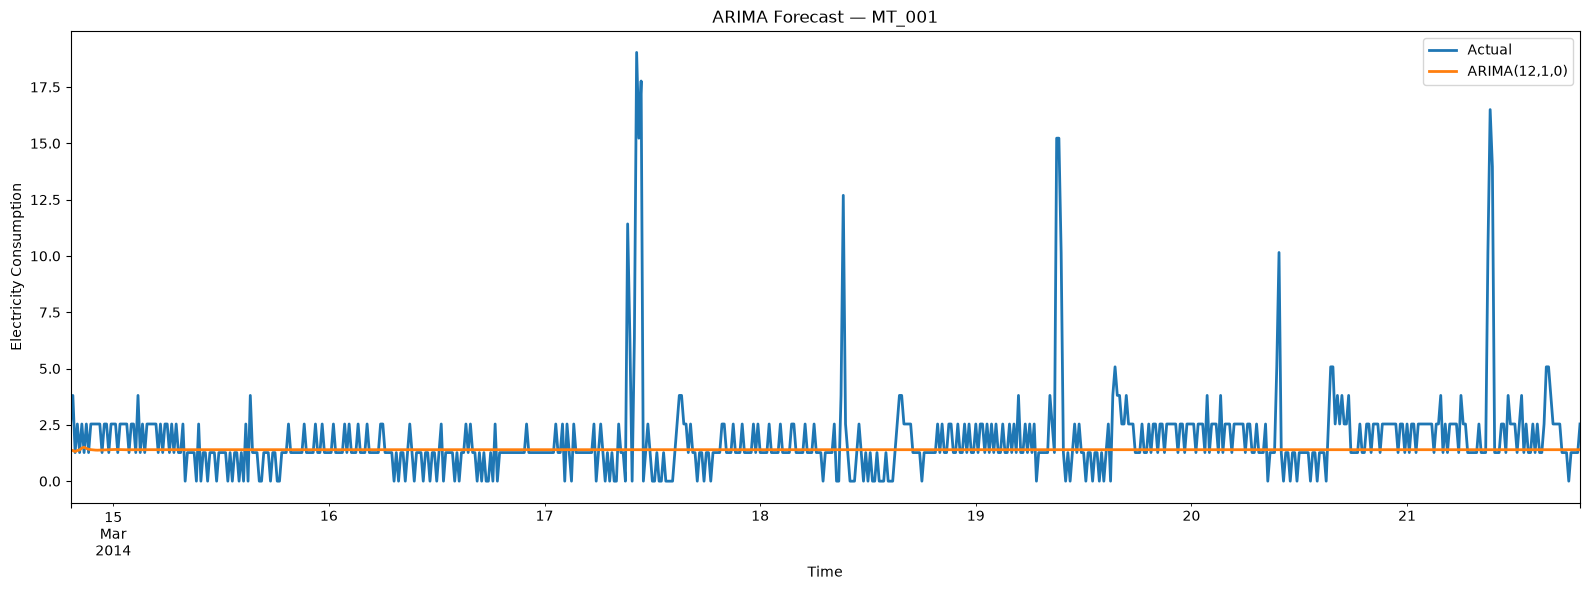

In [46]:
arima_forecast_week = arima_forecast.slice(
    forecast_start,
    forecast_end
)

plt.figure(figsize=(16, 6))

test_week.plot(
    label="Actual"
)

arima_forecast_week.plot(
    label=f"ARIMA({ARIMA_P},{ARIMA_D},{ARIMA_Q})"
)

plt.title(
    f"ARIMA Forecast — {SERIES_ID}"
)

plt.xlabel("Time")
plt.ylabel("Electricity Consumption")

plt.legend()
plt.tight_layout()
plt.show()

## Model Comparision

In [47]:
results = pd.DataFrame({
    "Model": [
        "Naive Seasonal (Daily)",
        "Naive Seasonal (Weekly)",
        f"ARIMA({ARIMA_P},{ARIMA_D},{ARIMA_Q})",
    ],
    "MAE": [
        daily_naive_mae,
        weekly_naive_mae,
        arima_mae,
    ],
    "RMSE": [
        daily_naive_rmse,
        weekly_naive_rmse,
        arima_rmse,
    ],
})

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(results)

,Model,MAE,RMSE
0,Naive Seasonal (Daily),3.566211,6.707616
1,Naive Seasonal (Weekly),3.650581,6.793700
2,"ARIMA(12,1,0)",3.537696,6.823710


In [48]:
best_model = results.iloc[0]

print("Best baseline model")
print("-------------------")
print("Model:", best_model["Model"])
print("MAE :", best_model["MAE"])
print("RMSE:", best_model["RMSE"])

Best baseline model
-------------------
Model: Naive Seasonal (Daily)
MAE : 3.5662106124883395
RMSE: 6.707615755577377


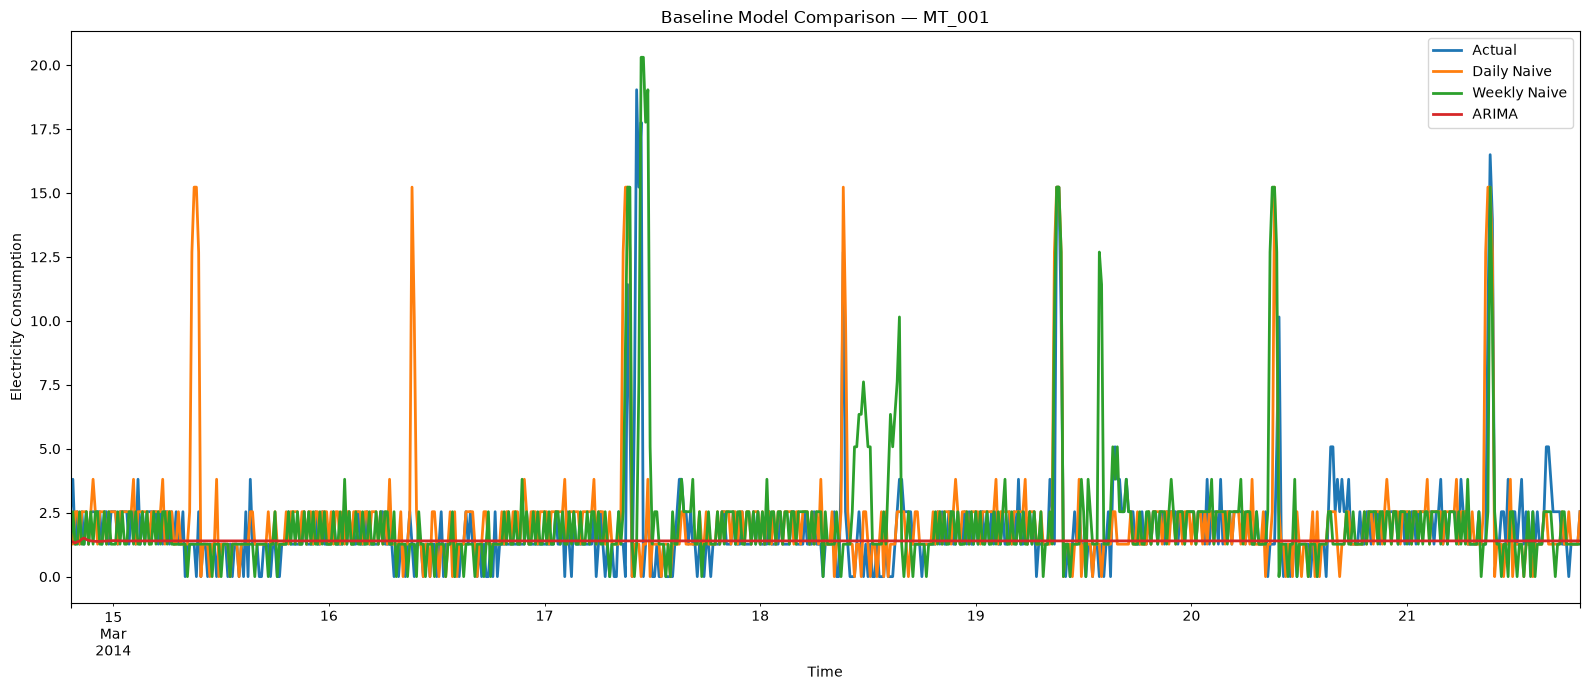

In [49]:
plt.figure(figsize=(16, 7))

test_week.plot(
    label="Actual"
)

daily_forecast_week.plot(
    label="Daily Naive"
)

weekly_forecast_week.plot(
    label="Weekly Naive"
)

arima_forecast_week.plot(
    label="ARIMA"
)

plt.title(
    f"Baseline Model Comparison — {SERIES_ID}"
)

plt.xlabel("Time")
plt.ylabel("Electricity Consumption")

plt.legend()
plt.tight_layout()
plt.show()

## Saving outputs

In [50]:

import darts


print(darts.__version__)
print(type(daily_naive_forecast))
print(type(daily_naive_forecast).__module__)
print([m for m in dir(daily_naive_forecast) if "data" in m.lower() or "frame" in m.lower() or "pandas" in m.lower()])

0.41.0
<class 'darts.timeseries.TimeSeries'>
darts.timeseries
['data_array', 'from_dataframe', 'from_group_dataframe', 'has_metadata', 'metadata', 'to_dataframe', 'with_metadata']


In [51]:
from pathlib import Path

from src.evaluation import (
    evaluate_multiple_forecasts,
    save_metrics,
    save_forecast,
)

RESULTS_DIR = PROJECT_ROOT / "results"

experiments = [
    {
        "model_name": "Naive Seasonal (Daily)",
        "actual": test[:96],
        "forecast": daily_naive_forecast[:96],
        "series_id": SERIES_ID,
        "horizon": 96,
    },
    {
    "model_name": "Naive Seasonal (Daily)",
    "actual": test[:192],
    "forecast": daily_naive_forecast[:192],
    "series_id": SERIES_ID,
    "horizon": 192,
    },

    {
        "model_name": "Naive Seasonal (Daily)",
        "actual": test[:672],
        "forecast": weekly_naive_forecast[:672],
        "series_id": SERIES_ID,
        "horizon": 672,
    },
    {
        "model_name": f"ARIMA({ARIMA_P},{ARIMA_D},{ARIMA_Q})",
        "actual": test[:96],
        "forecast": arima_forecast[:96],
        "series_id": SERIES_ID,
        "horizon": 96,
    },
    
]

baseline_metrics = evaluate_multiple_forecasts(
    experiments
)

save_metrics(
    baseline_metrics,
    RESULTS_DIR / "metrics.csv",
)

for experiment in experiments:

    save_forecast(
        forecast=experiment["forecast"],
        model_name=experiment["model_name"],
        series_id=experiment["series_id"],
        horizon=experiment["horizon"],
        path=RESULTS_DIR / "forecasts.csv",
    )

display(baseline_metrics)

,Model,Series_ID,Horizon,MAE,RMSE
0,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961
1,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641
2,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219
3,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251


In [52]:
from src.evaluation import load_metrics

metrics = load_metrics(RESULTS_DIR / "metrics.csv")
display(metrics)

,Model,Series_ID,Horizon,MAE,RMSE
0,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961
1,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641
2,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219
3,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251
